<a href="https://colab.research.google.com/github/Saksham-sri/Swiggy_Sales_Analysis/blob/main/Swiggy_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



In [150]:
df = pd.read_excel("/content/swiggy_data.xlsx")
df.head(5)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [152]:
df.isnull().sum()

,0
State,0
City,0
Order Date,0
Restaurant Name,0
Location,0
Category,0
Dish Name,0
Price (INR),0
Rating,0
Rating Count,0


In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [154]:
df.shape

(197430, 10)

In [155]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


 Identifing Outlier through visualization

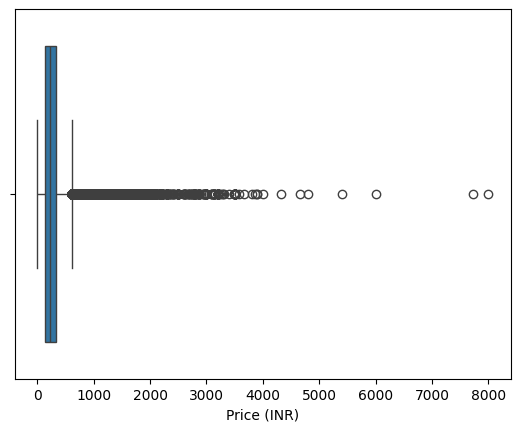

In [156]:
sns.boxplot(x = "Price (INR)",data = df)
plt.show()

In [157]:
# Removing Outlier
q1 = df["Price (INR)"].quantile(0.25)
q3 = df["Price (INR)"].quantile(0.75)
q1,q3


(np.float64(139.0), np.float64(329.0))

In [158]:
iqr = q3 - q1
iqr

np.float64(190.0)

In [159]:
min_range = q1 - (1.5 * iqr)
max_range = q3 + (1.5 * iqr)
min_range,max_range

(np.float64(-146.0), np.float64(614.0))

In [160]:
df = df[df["Price (INR)"] <= max_range]

In [161]:
# column name converting into lower case
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df = df.rename(columns={'Price (INR)': 'price_inr'})
df.head(2)

,state,city,order_date,restaurant_name,location,category,dish_name,price_(inr),rating,rating_count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25


**KPI ------**

**TOTAL SALES -------**

In [162]:
total_sales = df["price_(inr)"].sum()
print("Total_sales (INR) :", round(total_sales,2))

Total_sales (INR) : 43760976.64


**AVERAGE RATING -----**

In [163]:
average_rating = df["rating"].mean()
print("Average_Rating :", round(average_rating,2))

Average_Rating : 4.34


**AVERAAGE ORDER VALUE -----**

In [164]:
avg_order_val = df["price_(inr)"].mean()
print("Avg_order_value (INR) :", round(avg_order_val,2))

Avg_order_value (INR) : 233.32


**RATING COUNT ---**

In [165]:
rating_count = df["rating_count"].sum()
print("Total_Rating_count :", round(rating_count,2))

Total_Rating_count : 5491680


**TOTAL ORDERS ---**

In [166]:
total_orders =len(df)
print("Total_orders :", total_orders)

Total_orders : 187554


# **CHART DESIGN**

**MONTHLY SALES TREND**

In [167]:
df['order_date'] = pd.to_datetime(df['order_date'])  #pd.to_datetime is used to foramt the date time in proper way
df['YearMonth'] = df["order_date"].dt.to_period("M").astype(str)  #dt.to_period(M) is used to convert moth or extract  the month and year in like:2025-06

In [168]:
monthly_revenue = df.groupby("YearMonth")["price_(inr)"].sum().reset_index()
monthly_revenue

,YearMonth,price_(inr)
0,2025-01,5611496.14
1,2025-02,5182524.16
2,2025-03,5401848.92
3,2025-04,5478334.71
4,2025-05,5576657.85
5,2025-06,5407404.70
6,2025-07,5523542.77
7,2025-08,5579167.39


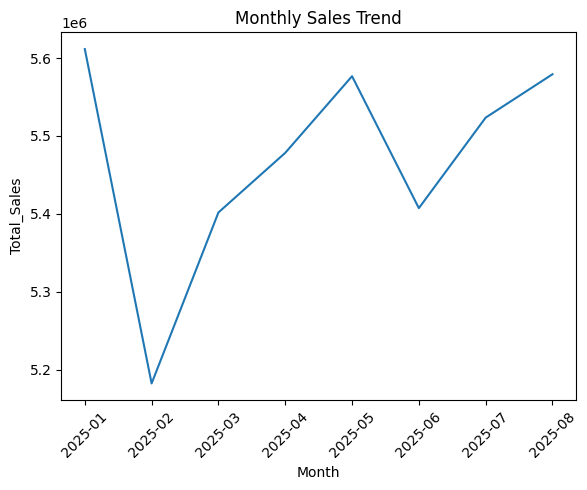

In [169]:
plt.figure(figsize=(6, 5))
plt.plot(monthly_revenue["YearMonth"], monthly_revenue['price_(inr)'] )
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total_Sales")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()

**DAILY SALES TREND**

In [170]:
df["DayName"] = pd.to_datetime(df['order_date']).dt.day_name()      #dt.day.name is used to extract day name like sunday,monday in column
daily_revenue = df.groupby('DayName')['price_(inr)'].sum().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
print(daily_revenue)

DayName
Monday       6135091.06
Tuesday      6071645.70
Wednesday    6250910.21
Thursday     6319217.79
Friday       6261526.17
Saturday     6432233.94
Sunday       6290351.77
Name: price_(inr), dtype: float64


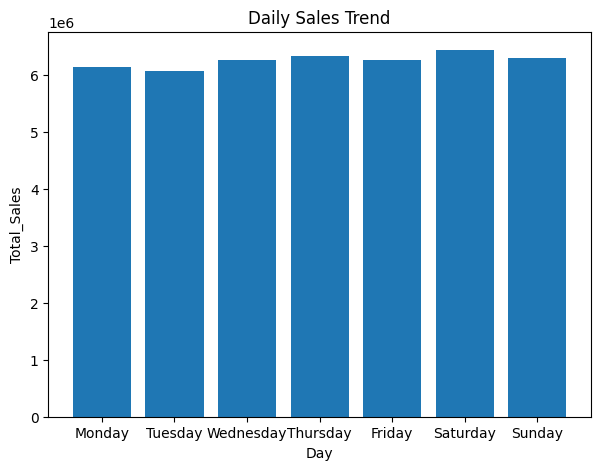

In [171]:
plt.figure(figsize=(7,5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.xlabel("Day")
plt.ylabel("Total_Sales")
plt.title("Daily Sales Trend")
plt.show()

**TOTAL SALES BY FOOD TYPE (VEG V/S NON VEG)**

In [172]:
non_veg_keywords = ["chicken","mutton","biryani", "egg","fish","prawn","kebab",
                    "non-veg"]
df["food_category"] = np.where(df["dish_name"].str.lower().str.contains("|".join(non_veg_keywords), na = False),"non-veg","veg")

In [173]:
food_revenue = df.groupby("food_category")["price_(inr)"].sum().reset_index()
food_revenue

,food_category,price_(inr)
0,non-veg,15346940.22
1,veg,28414036.42


In [174]:
fig = px.pie(
    food_revenue,
    values="price_(inr)",
    names="food_category",
    title="Renvue Contribution by Food Type",
    hole=0.5
)

In [175]:
fig.update_traces(
    textinfo = "label+percent",
    textposition = "inside",
    pull =[0.05,0]

)
fig.update_layout(
    height = 500,
    margin =dict(t=60,b=40,l=40,r=40)
)

fig.show()

TOTAL SALES BY STATE

In [176]:
fig = px.bar(
    df.groupby("state", as_index= False)["price_(inr)"].sum()
    .sort_values("price_(inr)", ascending= False),
    x="price_(inr)",
    y="state",
    title="Total Sales by State",
    orientation="h"
)
fig.update_layout(
    height = 600,
    yaxis = dict(autorange="reversed"),
    margin = dict(t=60,b=40,l=40,r=40)
)
fig.show()

**QUATERLY PERFORMANCE SUMMARY**

In [177]:
df['order_date'] = pd.to_datetime(df['order_date'])
df["Quater"] = df['order_date'].dt.to_period("Q").astype(str)
quaterly_summary = (
    df.groupby("Quater")
    .agg(
        total_sales = ("price_(inr)", "sum"),
        total_orders = ("order_date", "count"),
        avg_rating = ("rating", "mean")
    )
    .sort_values("Quater")
)

quaterly_summary

,total_sales,total_orders,avg_rating
Quater,,,
2025Q1,16195869.22,69375,4.340137
2025Q2,16462397.26,70490,4.337391
2025Q3,11102710.16,47689,4.339437


**TOP 10 CITIES BY SALES**

In [178]:
top_10_cities = (
    df.groupby("city")["price_(inr)"]
    .sum()
    .sort_values(ascending= False)
    .nlargest(10)
    .reset_index()

)
top_10_cities

,city,price_(inr)
0,Bengaluru,4475886.97
1,Mumbai,2560685.16
2,Ahmedabad,2351173.75
3,Lucknow,2294446.08
4,New Delhi,2282440.12
5,Hyderabad,2260857.40
6,Chennai,2241778.22
7,Chandigarh,2224291.80
8,Kolkata,2223993.03
9,Jaipur,2045225.60


In [179]:
fig = px.bar(top_10_cities,
             x="price_(inr)",
             y="city",
             title="Top 10 Cities by Sales",
             orientation="h",
             color_discrete_sequence= ["purple"]

)
fig.show()

**Which city has the highest average order value?**

In [180]:
Highest_avg_order_city = (df.groupby("city")["price_(inr)"].mean().sort_values(ascending= False).head(10).reset_index())
Highest_avg_order_city





,city,price_(inr)
0,Panaji,264.708748
1,Shillong,258.776714
2,Mumbai,255.761602
3,Gurgaon,245.592328
4,Lucknow,244.375980
5,Ahmedabad,242.814598
6,Shimla,239.796858
7,Aizawl,239.692747
8,New Delhi,238.350054
9,Chandigarh,235.924035


In [181]:
fig = px.bar(
    Highest_avg_order_city,
    x = "city",
    y = "price_(inr)",
    title = "Highest_avg_order_city",
    color_discrete_sequence = ["red"]
)
fig.show()

**PRICE V/S RATING CORRELATION**

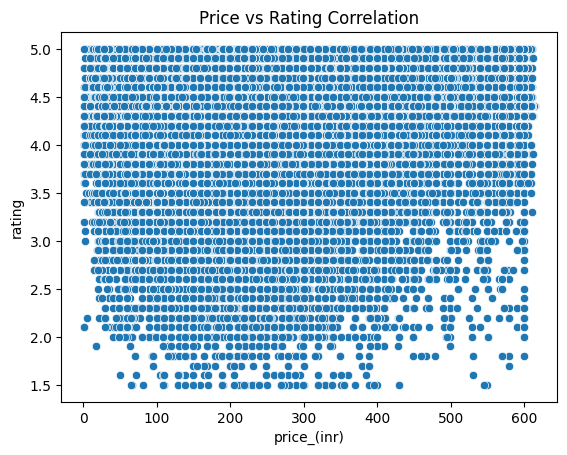

In [182]:
fig = sns.scatterplot(x="price_(inr)", y="rating", data=df)
plt.title("Price vs Rating Correlation")
plt.show()

**Which food type has the highest average rating?**

In [183]:
highest_avg_rating_food_type = df.groupby('food_category')['rating'].mean().sort_values(ascending=False).head(10).reset_index().round(2)
print(highest_avg_rating_food_type)

  food_category  rating
0           veg    4.35
1       non-veg    4.32


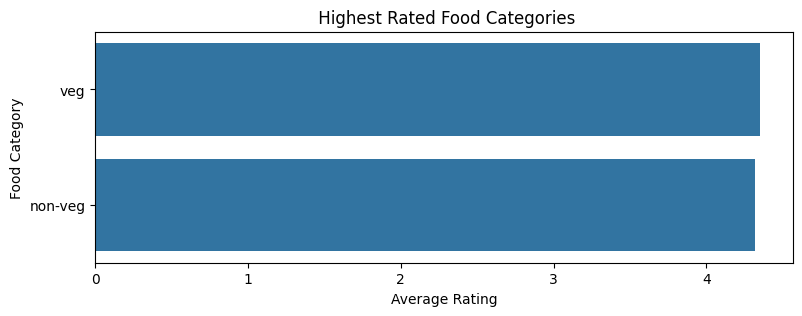

In [184]:
plt.figure(figsize=(9,3))

sns.barplot(
    x='rating',
    y='food_category',
    data=highest_avg_rating_food_type
)

plt.title(" Highest Rated Food Categories")
plt.xlabel("Average Rating")
plt.ylabel("Food Category")

plt.show()